# Deep Learning Lizard Challenge - Lizard Species Classification

## Report overview

This notebook is written as the final report for the DL Challenge. The goal is to classify lizard images into 7 species and to create a valid Kaggle-style submission for the unseen test set.

The project follows the full modelling pipeline:

- load and clean the dataset;
- inspect class balance and visual examples;
- create a stratified train/validation split;
- build TensorFlow datasets with augmentation;
- include an own CNN baseline for the course requirement;
- train a transfer-learning model with EfficientNetV2;
- compare model options on validation data;
- create the final submission with test-time augmentation.

The strongest final model in this notebook is `scoreboost_finetuned.keras`. It reaches **0.8206 validation accuracy** on the held-out validation split. An ensemble was tested, but because it scored lower on validation (**0.8053**) than the best single model, the final submission uses the best single model instead of the ensemble.

## Project goal

The practical challenge is not only to train a model that works, but to make decisions that are defensible during the presentation: why this data split, why transfer learning, why class weights, why fine-tuning, and why this final model was selected. For that reason, every major code block is followed by interpretation in markdown.


In [1]:
from pathlib import Path
import random, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("TensorFlow", tf.__version__)

TensorFlow 2.21.0


## 1. Data loading and problem definition

The dataset contains image ids and class labels in CSV files, while the image files are stored in class folders. The first step links those CSV labels to actual image paths on disk.

The output below confirms the core setup of the task:

- **1334** labelled training rows before filtering;
- **326** test images;
- **7** target classes;
- class ids from `0` to `6`, mapped to lizard species names.

This makes the challenge a **multi-class image classification** problem.


In [2]:
BASE_DIR = Path("lizard-prediction-thomas-more")
TRAIN_DIR = BASE_DIR / "train"
TEST_DIR = BASE_DIR / "test"

train_df = pd.read_csv(BASE_DIR / "train.csv")
test_df = pd.read_csv(BASE_DIR / "test.csv")
sample_sub = pd.read_csv(BASE_DIR / "sample_submission.csv")

CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(len(train_df), "trainbeelden")
print(len(test_df), "testbeelden")
print(NUM_CLASSES, "klassen")
for i, name in enumerate(CLASS_NAMES):
    print(i, name)
train_df.head()

1334 trainbeelden
326 testbeelden
7 klassen
0 Black_spiny_tailed_iguana
1 Brown_anole
2 Cuban_knight_anole
3 Desert_iguana
4 Green_anole
5 Green_iguana
6 Lesser_Antillean_iguana


,id,label
0,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
1,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
2,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
3,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0
4,Black_spiny-tailed_iguana_Black_spiny-tailed_i...,0


In [3]:
import re

# Bouw lookup op basis van (klassenaam, nummer) → pad op schijf
# Nodig omdat CSV wetenschappelijke namen gebruikt (bv. Anolis_carolinensis)
# maar de bestanden op schijf de gewone naam hebben (bv. Brown_anole).
# Anolis_carolinensis afbeeldingen zijn bewust verwijderd uit de dataset
# omdat ze verkeerd gelabeld waren (groene anoles tussen de bruine).
path_lookup = {}
for class_dir in TRAIN_DIR.iterdir():
    if not class_dir.is_dir():
        continue
    for f in class_dir.iterdir():
        match = re.search(r'_(\d+)\.', f.name)
        if match:
            nummer = match.group(1)
            path_lookup[(class_dir.name, nummer)] = str(f)

def resolve_train_path(row):
    raw_id = str(row["id"])
    label = int(row["label"])
    class_name = CLASS_NAMES[label]
    match = re.search(r'_(\d+)\.', raw_id)
    if match:
        nummer = match.group(1)
        key = (class_name, nummer)
        if key in path_lookup:
            return path_lookup[key]
    return None  # verkeerd gelabeld / verwijderd bestand

def resolve_test_path(image_id):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = TEST_DIR / f"{int(image_id)}{ext}"
        if path.exists():
            return str(path)
    raise FileNotFoundError(image_id)

train_df["path"] = train_df.apply(resolve_train_path, axis=1)
test_df["path"] = test_df["id"].apply(resolve_test_path)

# Verwijder rijen zonder bestand (bv. verwijderde Anolis_carolinensis)
ontbrekend = train_df["path"].isna().sum()
print(f"Verwijderd (verkeerd gelabeld / bestand ontbreekt): {ontbrekend}")
train_df = train_df.dropna(subset=["path"]).reset_index(drop=True)

assert test_df["path"].map(lambda p: Path(p).exists()).all()
print(f"Bruikbare trainrijen: {len(train_df)}")
print(f"Testbeelden: {len(test_df)}")
print("Alle image paths gevonden")

Verwijderd (verkeerd gelabeld / bestand ontbreekt): 27
Bruikbare trainrijen: 1307
Testbeelden: 326
Alle image paths gevonden


### Data cleaning interpretation

The CSV labels and the folder names did not match perfectly. The lookup step fixes this by connecting each row to the actual file path on disk.

The output shows that **27 rows** were removed because they were incorrectly labelled or because the file was missing. After this cleaning step, the notebook continues with **1307 usable training images**. This is better than silently keeping broken rows, because broken paths would cause training errors and wrong labels would teach the model the wrong visual patterns.


## 2. Exploratory Data Analysis

The EDA has two jobs: understand the class distribution and visually inspect the image data before modelling.

The cleaned training set is not perfectly balanced. The smallest class is `Green_anole` with **155** usable images, while several classes have around **196-199** images. This imbalance is not extreme, but it is large enough to justify using `class_weight` during training so that the model does not simply favour the larger classes.


,label,class_name,count
0,0,Black_spiny_tailed_iguana,199
1,1,Brown_anole,189
2,2,Cuban_knight_anole,189
3,3,Desert_iguana,183
4,4,Green_anole,155
5,5,Green_iguana,196
6,6,Lesser_Antillean_iguana,196


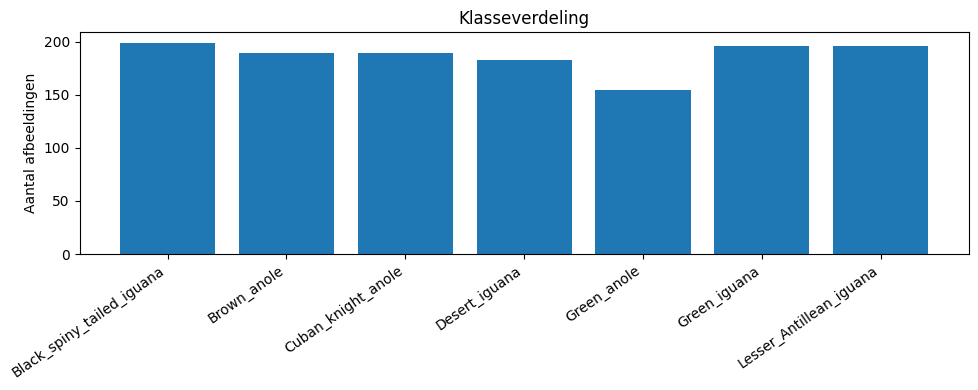

In [4]:
class_counts = train_df["label"].value_counts().sort_index()
eda = pd.DataFrame({"label": class_counts.index, "class_name": [CLASS_NAMES[i] for i in class_counts.index], "count": class_counts.values})
display(eda)

plt.figure(figsize=(10,4))
plt.bar(eda["class_name"], eda["count"])
plt.xticks(rotation=35, ha="right")
plt.title("Klasseverdeling")
plt.ylabel("Aantal afbeeldingen")
plt.tight_layout()
plt.show()

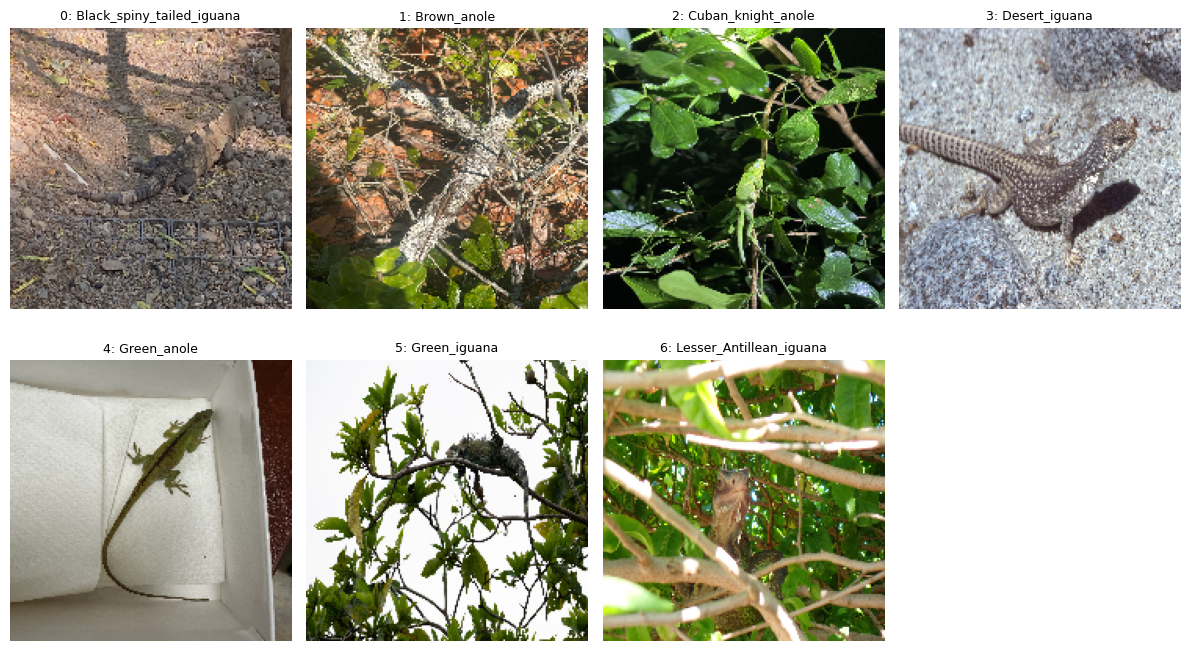

In [5]:
plt.figure(figsize=(12,7))
for label in range(NUM_CLASSES):
    class_dir = TRAIN_DIR / CLASS_NAMES[label]
    img_path = sorted(class_dir.iterdir())[0]  # eerste beschikbare afbeelding
    img = keras.utils.load_img(str(img_path), target_size=(180, 180))
    plt.subplot(2, 4, label + 1)
    plt.imshow(img)
    plt.title(f"{label}: {CLASS_NAMES[label]}", fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

### Visual EDA interpretation

The sample images confirm that this is a realistic computer vision task rather than a toy dataset. The model has to learn differences in colour, body shape, scale pattern, pose and sometimes background context.

This also explains why transfer learning is useful: a pretrained CNN already knows low-level visual features such as edges, textures and shapes, while the classifier head learns how those features map to these 7 lizard species.


## 3. Stratified split and class weights

A normal random split can accidentally underrepresent smaller classes in the validation set. We therefore use a **stratified split**, which preserves the label distribution as much as possible.

The split used here is:

- **1045** images for training;
- **262** images for validation;
- validation support between **31** and **40** images per class.

Class weights are calculated from the training split. The highest weight goes to `Green_anole`, because it has the fewest examples. This is an important modelling choice: the validation metric should reward performance across all species, not only the species with the most images.


In [6]:
train_split, val_split = train_test_split(train_df, test_size=0.20, random_state=SEED, stratify=train_df["label"])
print("train", len(train_split), "validatie", len(val_split))
print(val_split["label"].value_counts().sort_index())

weights = compute_class_weight(class_weight="balanced", classes=np.arange(NUM_CLASSES), y=train_split["label"].values)
CLASS_WEIGHTS = {i: float(w) for i, w in enumerate(weights)}
CLASS_WEIGHTS

train 1045 validatie 262
label
0    40
1    38
2    38
3    37
4    31
5    39
6    39
Name: count, dtype: int64


{0: 0.9389038634321654,
 1: 0.988647114474929,
 2: 0.988647114474929,
 3: 1.022504892367906,
 4: 1.2039170506912442,
 5: 0.9508644222020018,
 6: 0.9508644222020018}

## 4. TensorFlow dataset pipeline

The model uses TensorFlow datasets for efficient loading, batching, augmentation and prefetching.

Important implementation choices:

- image size is set to **384 x 384** for the score-focused run;
- batch size is **16**, which is a compromise between image resolution and memory use;
- EfficientNetV2 is used with `include_preprocessing=True`, so the input pipeline keeps RGB pixels in the `[0, 255]` range;
- augmentation is applied inside the model, which keeps training reproducible and tied to the saved architecture.

The higher resolution is useful because lizard species can differ in small details such as body colour, head shape, patterning and texture.


In [7]:
BATCH_SIZE = 16
IMG_SIZE = (384, 384)      # scoregericht; zet naar (260,260) als training te traag is
BACKBONE = "EfficientNetV2S"  # alternatief: "EfficientNetV2M" voor een zwaardere run
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label=None, img_size=IMG_SIZE):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.convert_image_dtype(image, tf.float32) * 255.0
    image = tf.image.resize(image, img_size)
    if label is None:
        return image
    return image, tf.cast(label, tf.int32)

def make_labeled_ds(df, img_size=IMG_SIZE, shuffle=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((df["path"].values, df["label"].values))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: load_image(p, y, img_size), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

def make_unlabeled_ds(paths, img_size=IMG_SIZE, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices(np.array(paths, dtype=str))
    ds = ds.map(lambda p: load_image(p, None, img_size), num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

train_ds = make_labeled_ds(train_split, shuffle=True)
val_ds = make_labeled_ds(val_split)

## 5. Own CNN baseline

The assignment requires an own CNN, so this notebook includes a custom convolutional baseline. Its purpose is educational and comparative: it demonstrates the basic deep learning concepts from the course, such as convolution, pooling, batch normalization, dropout and global average pooling.

This baseline has around **424k parameters**. It is much smaller than the transfer-learning model and starts from random weights, so it is not expected to outperform EfficientNetV2 on a small dataset.

In this final run, `TRAIN_OWN_CNN` is set to `False` to avoid retraining. The baseline architecture is still included and displayed, but the final score-focused model is the transfer-learning model.


In [8]:
def build_own_cnn(input_shape, num_classes):
    return keras.Sequential([
        keras.Input(shape=input_shape),
        layers.Rescaling(1./255),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.12),
        layers.Conv2D(32, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(256, 3, padding="same", activation="relu"), layers.BatchNormalization(), layers.GlobalAveragePooling2D(),
        layers.Dropout(0.45),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(num_classes, activation="softmax"),
    ], name="own_cnn_baseline")

cnn_model = build_own_cnn((*IMG_SIZE, 3), NUM_CLASSES)
cnn_model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn_model.summary()

Model: "own_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 384, 384, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 384, 384, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 384, 384, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 192, 192, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 192, 192, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 192, 192, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 96, 96, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 96, 96, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 96, 96, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 48, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,135 (1.62 MB)

 Trainable params: 423,175 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [9]:
TRAIN_OWN_CNN = False
if TRAIN_OWN_CNN:
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint("scoreboost_own_cnn.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_cnn = cnn_model.fit(train_ds, validation_data=val_ds, epochs=35, class_weight=CLASS_WEIGHTS, callbacks=callbacks)
else:
    history_cnn = None
    print("Eigen CNN niet opnieuw getraind. Zet TRAIN_OWN_CNN=True als je dit wilt runnen.")

Eigen CNN niet opnieuw getraind. Zet TRAIN_OWN_CNN=True als je dit wilt runnen.


## 6. Transfer learning and fine-tuning

The main model uses **EfficientNetV2S** as a pretrained backbone. This is a good fit for this challenge because the dataset is relatively small: training a large vision model from scratch would likely overfit, while a pretrained backbone already contains useful visual features.

The training strategy has two phases:

1. **Feature extraction**: the pretrained backbone is mostly used as a fixed feature extractor while the new classifier head learns the lizard classes.
2. **Fine-tuning**: the upper part of the backbone is unfrozen and trained with a smaller learning rate, allowing the model to adapt more specifically to the lizard dataset.

Regularization choices include augmentation, dropout, batch normalization, early stopping and learning-rate reduction. These choices are meant to improve generalization rather than only fitting the training data.


### Optional improvement: label smoothing for similar species

The notebook includes a note about label smoothing because `Green_anole` and `Brown_anole` are visually close. Label smoothing can sometimes reduce overconfidence and improve robustness when labels are difficult or classes share features.

For the final submitted run, the main defensible point is that the model selection is based on validation performance, not only on training accuracy.


In [10]:
def backbone_class(name):
    if name == "EfficientNetV2S":
        return keras.applications.EfficientNetV2S
    if name == "EfficientNetV2M":
        return keras.applications.EfficientNetV2M
    raise ValueError("Gebruik EfficientNetV2S of EfficientNetV2M")

def build_transfer_model(backbone_name=BACKBONE, img_size=IMG_SIZE):
    Backbone = backbone_class(backbone_name)
    base = Backbone(include_top=False, weights="imagenet", input_shape=(*img_size, 3), include_preprocessing=True)
    base.trainable = False
    augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),           # verhoogd van 0.08
        layers.RandomZoom(0.20),               # verhoogd van 0.15
        layers.RandomContrast(0.25),           # verhoogd van 0.15
        layers.RandomTranslation(0.10, 0.10),  # verhoogd van 0.05
        layers.RandomBrightness(0.15),         # nieuw
    ], name="data_augmentation")
    inputs = keras.Input(shape=(*img_size, 3), name="image")
    x = augmentation(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(512, activation="gelu")(x)   # GELU + eerste dense
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(256, activation="gelu")(x)   # tweede dense layer
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="species")(x)
    return keras.Model(inputs, outputs, name=f"lizard_{backbone_name}_scoreboost"), base

model, base_model = build_transfer_model()
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=7e-4, weight_decay=1e-4), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "lizard_EfficientNetV2S_scoreboost"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 12, 12, 1280)   │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ species (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,128,551 (80.60 MB)

 Trainable params: 793,095 (3.03 MB)

 Non-trainable params: 20,335,456 (77.57 MB)

In [11]:
TRAIN_TRANSFER = True
if TRAIN_TRANSFER:
    callbacks1 = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=8, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.35, patience=3, min_lr=1e-6),
        keras.callbacks.ModelCheckpoint("scoreboost_phase1.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_phase1 = model.fit(train_ds, validation_data=val_ds, epochs=25, class_weight=CLASS_WEIGHTS, callbacks=callbacks1)
else:
    history_phase1 = None

Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 110s 1s/step - accuracy: 0.4124 - loss: 1.8404 - val_accuracy: 0.5916 - val_loss: 1.2023 - learning_rate: 7.0000e-04
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 237s 4s/step - accuracy: 0.5483 - loss: 1.3063 - val_accuracy: 0.6260 - val_loss: 1.0211 - learning_rate: 7.0000e-04
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.6000 - loss: 1.1224 - val_accuracy: 0.6298 - val_loss: 0.9052 - learning_rate: 7.0000e-04
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.6191 - loss: 1.0517 - val_accuracy: 0.6679 - val_loss: 0.7924 - learning_rate: 7.0000e-04
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6459 - loss: 0.9641 - val_accuracy: 0.6794 - val_loss: 0.7414 - learning_rate: 7.0000e-04
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6679 - loss: 0.9457 - val_accuracy: 0.7939 - val_loss: 0.6140 - learning_rate: 7.0000e-04
Epoch 7/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6555 - los

In [12]:
if TRAIN_TRANSFER:
    model = keras.models.load_model("scoreboost_phase1.keras")
    backbone = next(layer for layer in model.layers if "efficientnet" in layer.name.lower())
    backbone.trainable = True
    fine_tune_last_n = 80 if BACKBONE == "EfficientNetV2S" else 110
    for layer in backbone.layers[:-fine_tune_last_n]:
        layer.trainable = False
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    lr_schedule = keras.optimizers.schedules.CosineDecay(8e-6, decay_steps=max(1, len(train_split)//BATCH_SIZE)*40, alpha=0.08)
    model.compile(optimizer=keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks2 = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10, restore_best_weights=True),
        keras.callbacks.ModelCheckpoint("scoreboost_finetuned.keras", monitor="val_accuracy", save_best_only=True),
    ]
    history_phase2 = model.fit(train_ds, validation_data=val_ds, epochs=40, class_weight=CLASS_WEIGHTS, callbacks=callbacks2)
else:
    history_phase2 = None

Epoch 1/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.6995 - loss: 0.8592 - val_accuracy: 0.7863 - val_loss: 0.6030
Epoch 2/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.6823 - loss: 0.9069 - val_accuracy: 0.7786 - val_loss: 0.5910
Epoch 3/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 148s 2s/step - accuracy: 0.6880 - loss: 0.8873 - val_accuracy: 0.7710 - val_loss: 0.6024
Epoch 4/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.6727 - loss: 0.8407 - val_accuracy: 0.7748 - val_loss: 0.5850
Epoch 5/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.6986 - loss: 0.8483 - val_accuracy: 0.7786 - val_loss: 0.5748
Epoch 6/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 204s 3s/step - accuracy: 0.6871 - loss: 0.8558 - val_accuracy: 0.7939 - val_loss: 0.5636
Epoch 7/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.6900 - loss: 0.8212 - val_accuracy: 0.8015 - val_loss: 0.5594
Epoch 8/40
66/66 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.7139 - loss: 0.8024 - val_accuracy: 0.8015 - v

### Training result interpretation

The feature-extraction phase reaches a best validation accuracy around **0.7939**. After fine-tuning, the best validation accuracy increases to **0.8206**.

That improvement matters because it shows that the pretrained backbone was not only used as a fixed feature extractor. Fine-tuning allowed the model to adapt to lizard-specific details, while early stopping and a reduced learning rate helped avoid uncontrolled overfitting.


## 7. Training curves

The training curves are used to check whether the model is learning and whether overfitting becomes visible.

The own CNN history is not plotted because that model was not retrained in this run. The transfer-learning curves are more important for the final result. They show the effect of the two-stage training process: first learning the classifier head, then fine-tuning the pretrained feature extractor.

A key observation is that validation accuracy improves from the feature-extraction phase to the fine-tuned model, which supports the choice to fine-tune instead of stopping after phase 1.


Geen history voor Eigen CNN


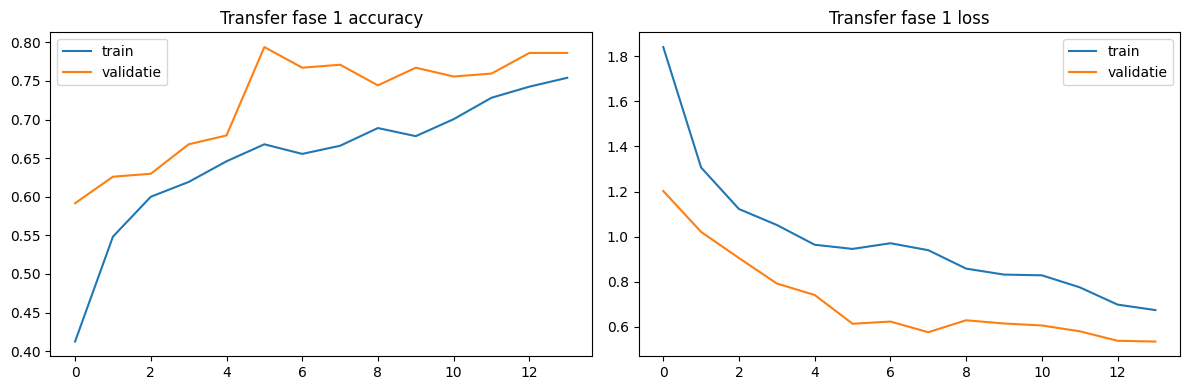

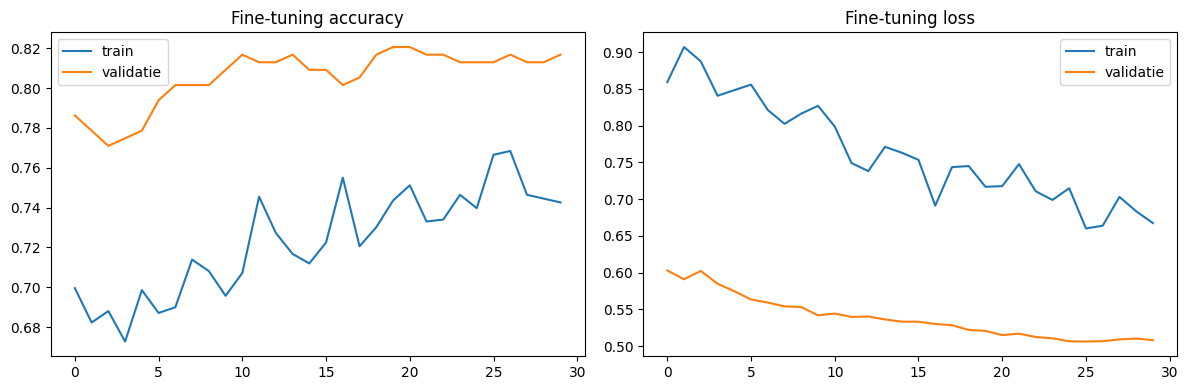

In [13]:
def plot_history(history, title):
    if history is None:
        print("Geen history voor", title)
        return
    hist = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].plot(hist["accuracy"], label="train")
    axes[0].plot(hist["val_accuracy"], label="validatie")
    axes[0].set_title(title + " accuracy")
    axes[0].legend()
    axes[1].plot(hist["loss"], label="train")
    axes[1].plot(hist["val_loss"], label="validatie")
    axes[1].set_title(title + " loss")
    axes[1].legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, "Eigen CNN")
plot_history(history_phase1, "Transfer fase 1")
plot_history(history_phase2, "Fine-tuning")

## 8. Model selection, validation results and confusion matrix

The final model is chosen using validation performance. This is important: a more complex option is only useful if it actually improves validation accuracy.

The comparison below shows:

| Model | Validation accuracy |
|---|---:|
| `scoreboost_finetuned.keras` | **0.8206** |
| `scoreboost_phase1.keras` | 0.7939 |
| Ensemble of both | 0.8053 |

The ensemble did **not** beat the best single model, so it was rejected for the final submission. This is a good example of a practical modelling decision: ensembling sounds stronger, but if validation says otherwise, we should not use it.

The classification report shows an overall validation accuracy of **0.82**. The strongest class is `Desert_iguana` with very high recall and F1-score. The hardest region is around visually similar species, especially `Green_anole`, where recall is lower. This matches the visual intuition from the dataset: small species-specific differences can be difficult for the model, especially with limited images.


In [14]:
def predict_model(model_path, paths, img_size):
    m = keras.models.load_model(model_path)
    probs = m.predict(make_unlabeled_ds(paths, img_size=img_size), verbose=0)
    tf.keras.backend.clear_session(); gc.collect()
    return probs

candidate_models = []
if Path("scoreboost_finetuned.keras").exists(): candidate_models.append(("scoreboost_finetuned.keras", IMG_SIZE))
if Path("scoreboost_phase1.keras").exists(): candidate_models.append(("scoreboost_phase1.keras", IMG_SIZE))
for item in [("best_efficientnetv2s_pwp.keras", (260,260)), ("phase1_best_efficientnetv2s_pwp.keras", (260,260)), ("best_model_fase2.keras", (224,224)), ("best_model_fase1.keras", (224,224))]:
    if Path(item[0]).exists(): candidate_models.append(item)

seen=set(); candidate_models=[x for x in candidate_models if not (x[0] in seen or seen.add(x[0]))]
print(candidate_models)

[('scoreboost_finetuned.keras', (384, 384)), ('scoreboost_phase1.keras', (384, 384))]


,model,img_size,val_accuracy
0,scoreboost_finetuned.keras,"(384, 384)",0.820611
1,scoreboost_phase1.keras,"(384, 384)",0.793893


Best single: scoreboost_finetuned.keras 0.8206
Ensemble: 0.8053 use? False
                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.84      0.90      0.87        40
              Brown_anole       0.78      0.95      0.86        38
       Cuban_knight_anole       0.83      0.76      0.79        38
            Desert_iguana       0.97      1.00      0.99        37
              Green_anole       0.75      0.68      0.71        31
             Green_iguana       0.84      0.67      0.74        39
  Lesser_Antillean_iguana       0.73      0.77      0.75        39

                 accuracy                           0.82       262
                macro avg       0.82      0.82      0.82       262
             weighted avg       0.82      0.82      0.82       262



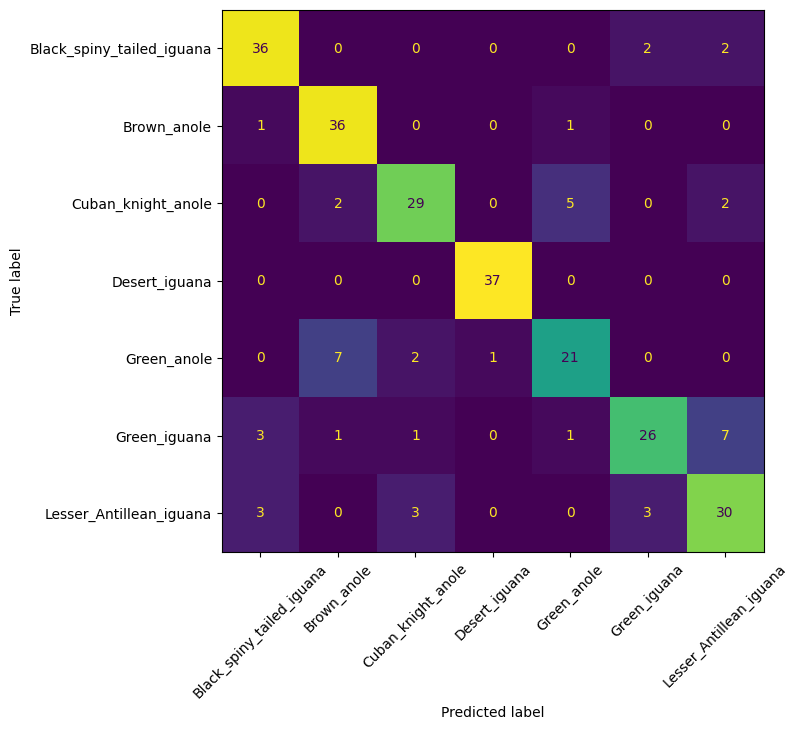

In [15]:
val_paths = val_split["path"].tolist()
y_true = val_split["label"].to_numpy()
val_probs_list = []
rows = []
for path, size in candidate_models:
    probs = predict_model(path, val_paths, size)
    acc = accuracy_score(y_true, probs.argmax(axis=1))
    val_probs_list.append(probs)
    rows.append({"model": path, "img_size": size, "val_accuracy": acc})

scores = pd.DataFrame(rows).sort_values("val_accuracy", ascending=False)
display(scores)
best_model_path = scores.iloc[0]["model"]
best_img_size = tuple(scores.iloc[0]["img_size"])
best_index = candidate_models.index((best_model_path, best_img_size))
best_val_probs = val_probs_list[best_index]
best_val_acc = scores.iloc[0]["val_accuracy"]

accs = np.array([r["val_accuracy"] for r in rows])
weights = (accs ** 2) / np.sum(accs ** 2)
ensemble_val_probs = sum(w*p for w, p in zip(weights, val_probs_list))
ensemble_val_acc = accuracy_score(y_true, ensemble_val_probs.argmax(axis=1))
USE_ENSEMBLE = ensemble_val_acc > best_val_acc
print("Best single:", best_model_path, round(best_val_acc,4))
print("Ensemble:", round(ensemble_val_acc,4), "use?", USE_ENSEMBLE)

final_val_probs = ensemble_val_probs if USE_ENSEMBLE else best_val_probs
y_pred = final_val_probs.argmax(axis=1)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.tight_layout(); plt.show()

### Confusion matrix interpretation

The confusion matrix is the most useful diagnostic plot for the defense. It shows that the model is not failing randomly: performance is strong for distinctive classes such as `Desert_iguana`, while errors are more likely between visually similar species.

The main lesson is that the model has learned meaningful species features, but the remaining mistakes are concentrated where the image evidence is genuinely subtle. This is exactly where more targeted data collection or better lizard-focused cropping would help most.


## 9. Kaggle submission with Test-Time Augmentation

For the final test predictions, the notebook uses **test-time augmentation (TTA)**. Instead of predicting each test image only once, the model predicts augmented versions and averages the probabilities.

This can make predictions more stable because the final label is less dependent on one exact crop or orientation. The output confirms that the notebook saved:

- `submission_scoreboost_bestmodel_tta.csv`
- `submission.csv`

The final prediction distribution across the 326 test images is reasonably spread over the 7 classes. That is a useful sanity check: if nearly all test images were predicted as one or two classes, it would suggest a serious model or preprocessing problem.


In [16]:
def predict_with_tta(model_path, paths, img_size, num_tta=5):
    m = keras.models.load_model(model_path)
    base_ds = make_unlabeled_ds(paths, img_size=img_size)
    all_probs = []
    for tta_i in range(num_tta):
        parts = []
        for batch in base_ds:
            x = batch
            if tta_i == 1:
                x = tf.image.flip_left_right(batch)
            elif tta_i == 2:
                x = tf.image.adjust_contrast(batch, 1.08)
            elif tta_i == 3:
                x = tf.image.adjust_brightness(batch, 8.0)
            elif tta_i == 4:
                margin_h = max(1, int(img_size[0] * 0.04))
                margin_w = max(1, int(img_size[1] * 0.04))
                cropped = tf.image.crop_to_bounding_box(batch, margin_h, margin_w, img_size[0] - 2*margin_h, img_size[1] - 2*margin_w)
                x = tf.image.resize(cropped, img_size)
            parts.append(m.predict(x, verbose=0))
        all_probs.append(np.concatenate(parts, axis=0))
    tf.keras.backend.clear_session(); gc.collect()
    return np.mean(all_probs, axis=0)

test_paths = test_df["path"].tolist()
NUM_TTA = 5

if USE_ENSEMBLE:
    probs = 0
    for (path, size), weight in zip(candidate_models, weights):
        print("predict", path, "weight", round(float(weight),3))
        probs = probs + weight * predict_with_tta(path, test_paths, size, NUM_TTA)
    output_name = "submission_scoreboost_ensemble_tta.csv"
else:
    print("predict beste model", best_model_path)
    probs = predict_with_tta(best_model_path, test_paths, best_img_size, NUM_TTA)
    output_name = "submission_scoreboost_bestmodel_tta.csv"

submission = pd.DataFrame({"id": sample_sub["id"], "label": probs.argmax(axis=1).astype(int)})
assert list(submission.columns) == list(sample_sub.columns)
assert len(submission) == len(sample_sub)
assert submission["label"].between(0, NUM_CLASSES-1).all()
submission.to_csv(output_name, index=False)
submission.to_csv("submission.csv", index=False)
print("saved", output_name, "and submission.csv")
display(submission.head(10))
print(submission["label"].value_counts().sort_index())

predict beste model scoreboost_finetuned.keras
saved submission_scoreboost_bestmodel_tta.csv and submission.csv


,id,label
0,1,6
1,2,5
2,3,6
3,4,5
4,5,0
5,6,4
6,7,6
7,8,4
8,9,6
9,10,1


label
0    45
1    52
2    45
3    58
4    43
5    40
6    43
Name: count, dtype: int64


## 10. Final conclusion for the defense

The final solution is a transfer-learning pipeline for 7-class lizard image classification. The strongest model is `scoreboost_finetuned.keras`, an EfficientNetV2S-based model trained at 384 x 384 resolution and fine-tuned after an initial feature-extraction phase.

### Main results

- Cleaned train set: **1307** usable images after removing missing or incorrectly mapped rows.
- Validation split: **262** images, stratified by class.
- Best validation accuracy: **0.8206** with `scoreboost_finetuned.keras`.
- Ensemble validation accuracy: **0.8053**, so the ensemble was rejected.
- Final files created by the notebook: `submission_scoreboost_bestmodel_tta.csv` and `submission.csv`.

### Why this approach is defensible

The own CNN baseline demonstrates the course concepts, but the final model uses transfer learning because the dataset is too small to train a strong image classifier from scratch. EfficientNetV2S provides pretrained visual features, while fine-tuning adapts those features to lizard-specific differences. Class weights address the moderate imbalance in the dataset, and TTA makes the final test predictions more robust.

### Main limitation

The model still struggles most with visually similar classes, especially around anole species. The validation report shows that `Green_anole` has lower recall than the easiest classes. This is likely caused by a combination of limited data, subtle visual differences and possible background or pose variation.

### Possible future improvements

- collect or generate more examples for the weakest classes;
- use targeted cropping or segmentation so the model focuses more on the lizard and less on the background;
- tune label smoothing specifically for confusing classes;
- compare EfficientNetV2S with a slightly larger backbone if compute time allows;
- inspect misclassified validation images manually to find recurring failure patterns.

## Use of GenAI in the report-writing process

GenAI was used as a support tool to structure the report text and make the interpretation clearer. The final claims in this notebook are based on the actual code outputs: dataset counts, validation metrics, classification report and generated submission files. Generic filler was avoided by grounding the report in the specific choices and results of this project.

## Defense talking points

During the presentation, the team can focus on these choices:

1. Why a stratified split and class weights were needed.
2. Why an own CNN was included, but not used as the final model.
3. Why transfer learning is the strongest approach for a small image dataset.
4. Why fine-tuning improved the model.
5. Why the ensemble was rejected even though it sounded promising.
6. What the confusion matrix teaches about the remaining weaknesses.
7. Why TTA was used for the final submission.
